# 08 — Coach spec: clean dataset, simple binary classification, all vehicles

**Explicit spec, as given today, followed exactly:**
- Use all 4 raw CSVs (daily, heavy, moderate, rare) — merged, not single-vehicle.
- Original features only — the 10 raw sensor columns, no rolling/lag/calendar engineering.
- Engineered target only — `Fault_Within_6h`, the forward-looking label (kept, since deriving it
  is unavoidable to have any forecasting target at all — "engineered target" is read as "the
  derived label," not "no derivation whatsoever").
- Train/test split **with stratification** (not chronological).
- Logistic regression.

**One tension worth stating plainly, not hiding:** a stratified random split does not respect time
order — rows from the same vehicle's adjacent hours can land on both sides of the split, which is
the exact leakage risk the chronological split in the other rebuild notebooks exists to prevent
(rolling/lag features in *this* notebook are absent, so that specific risk doesn't apply here, but
the target itself still has short-range temporal structure). Following the given instruction as
specified; noting the tradeoff here so it's traceable, not silently accepted.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RAW_SENSOR_COLS = ["SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
                    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure"]
FAULT_CODES = {"P0MR", "P0MT", "P0B"}
VEHICLES = ["daily_user", "heavy_user", "moderate_user", "rare_user"]


## 1. Load and merge all 4 vehicles

In [2]:
def load_vehicle(name):
    df = pd.read_csv(f"../data/raw/{name}.csv")
    df = df.rename(columns={"Unnamed: 0": "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["DTC"] = df["DTC"].astype(str)
    df["user_profile"] = name
    return df.sort_values("timestamp").reset_index(drop=True)


all_dfs = [load_vehicle(v) for v in VEHICLES]
df = pd.concat(all_dfs, ignore_index=True)
print(f"Merged: {len(df):,} rows across {df['user_profile'].nunique()} vehicles")
print(df["user_profile"].value_counts())


Merged: 175,200 rows across 4 vehicles
user_profile
daily_user       43800
heavy_user       43800
moderate_user    43800
rare_user        43800
Name: count, dtype: int64


## 2. Derive Fault_Label (same documented rule as the rest of the project) and the forward-looking target

In [3]:
def label_row(dtc: str) -> str:
    if dtc == "0":
        return "Normal"
    codes = dtc.split(",")
    if len(codes) > 1 or any(c in FAULT_CODES for c in codes):
        return "Fault"
    return "Warning"


df["Fault_Label"] = df["DTC"].apply(label_row)
df["is_fault"] = df["Fault_Label"] != "Normal"


def fault_within_next_n_hours(is_fault_series, n):
    reversed_series = is_fault_series[::-1]
    excludes_current = reversed_series.shift(1)
    forward_max = excludes_current.rolling(window=n, min_periods=n).max()
    return forward_max[::-1]


# Forward window computed PER VEHICLE (groupby), so no vehicle\'s future bleeds into another\'s —
# this part of the pipeline has to stay per-group even though the final split ignores time order.
df["Fault_Within_6h"] = df.groupby("user_profile")["is_fault"].transform(
    lambda s: fault_within_next_n_hours(s, 6)
)

print("Fault_Within_6h defined rows:", df["Fault_Within_6h"].notna().sum(), "/", len(df))
print(df["Fault_Within_6h"].dropna().value_counts(normalize=True).mul(100).round(6))


Fault_Within_6h defined rows: 175176 / 175200
Fault_Within_6h
0.0    90.949103
1.0     9.050897
Name: proportion, dtype: float64


In [4]:
df_model = df.dropna(subset=["Fault_Within_6h"]).copy()
df_model["Fault_Within_6h"] = df_model["Fault_Within_6h"].astype(bool)
print(f"{len(df_model):,} rows with a defined target, {len(RAW_SENSOR_COLS)} original features only.")


175,176 rows with a defined target, 10 original features only.


### Save the merged, cleaned, all-4-vehicle dataset as an actual file

In [5]:
import os

os.makedirs("../data/processed", exist_ok=True)
df_model.to_csv("../data/processed/all_vehicles_cleaned.csv", index=False)
print(f"Saved {len(df_model):,} rows x {len(df_model.columns)} columns to "
      f"../data/processed/all_vehicles_cleaned.csv")
print("Columns:", df_model.columns.tolist())


Saved 175,176 rows x 16 columns to ../data/processed/all_vehicles_cleaned.csv
Columns: ['timestamp', 'SOC', 'SOH', 'Charging_Cycles', 'Battery_Temp', 'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear', 'Charging_Voltage', 'Tire_Pressure', 'DTC', 'user_profile', 'Fault_Label', 'is_fault', 'Fault_Within_6h']


## 3. Train/test split — stratified, as specified (not chronological)

In [6]:
X = df_model[RAW_SENSOR_COLS]
y = df_model["Fault_Within_6h"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {len(X_train):,} rows, {y_train.mean()*100:.2f}% positive")
print(f"Test:  {len(X_test):,} rows, {y_test.mean()*100:.2f}% positive")
print("(Stratification matches the positive rate between train and test by construction.)")


Train: 140,140 rows, 9.05% positive
Test:  35,036 rows, 9.05% positive
(Stratification matches the positive rate between train and test by construction.)


## 4. Logistic regression — balanced weights, scaled inputs, categorical column handled properly

`Charging_Voltage` is categorical (only 240 / 400 — see Section on feature types discussed with the
coach). Feeding it straight into `StandardScaler` alongside the continuous sensors treats it as if
it had a meaningful numeric magnitude, which isn't the textbook-correct approach for a categorical
column. Fixed here with a `ColumnTransformer`: the 9 continuous sensors get scaled, `Charging_Voltage`
gets one-hot/binary-encoded instead.


In [7]:
CONTINUOUS_COLS = [c for c in RAW_SENSOR_COLS if c != "Charging_Voltage"]
CATEGORICAL_COLS = ["Charging_Voltage"]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), CONTINUOUS_COLS),
    ("onehot", OneHotEncoder(drop="if_binary"), CATEGORICAL_COLS),
])

logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)),
])
logreg.fit(X_train, y_train)

train_pred = logreg.predict(X_train)
test_pred = logreg.predict(X_test)

for name, y_true, pred in [("TRAIN", y_train, train_pred), ("TEST", y_test, test_pred)]:
    print("=" * 55)
    print(name)
    print("=" * 55)
    print(classification_report(y_true, pred, labels=[False, True], digits=6, zero_division=0))


TRAIN
              precision    recall  f1-score   support

       False   0.932817  0.662990  0.775091    127456
        True   0.133153  0.520183  0.212032     12684

    accuracy                       0.650064    140140
   macro avg   0.532985  0.591586  0.493561    140140
weighted avg   0.860440  0.650064  0.724129    140140

TEST
              precision    recall  f1-score   support

       False   0.932756  0.662545  0.774767     31865
        True   0.132962  0.520025  0.211777      3171

    accuracy                       0.649646     35036
   macro avg   0.532859  0.591285  0.493272     35036
weighted avg   0.860369  0.649646  0.723812     35036



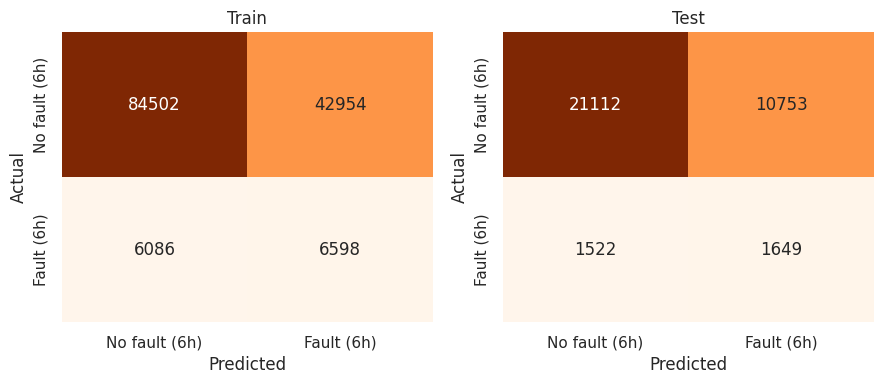

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, y_true, pred) in zip(axes, [("Train", y_train, train_pred), ("Test", y_test, test_pred)]):
    cm = confusion_matrix(y_true, pred, labels=[False, True])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, cbar=False,
                xticklabels=["No fault (6h)", "Fault (6h)"], yticklabels=["No fault (6h)", "Fault (6h)"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 5. Metric check — DummyClassifier, and why macro F1 is demoted from here on

Coach's point, checked directly: a model that never predicts a fault at all still scores a
misleadingly OK-looking macro F1, because it averages in the negative class's near-perfect score.
Positive-class F1 (fault = positive) doesn't have that problem — it goes to exactly 0 for a useless
model. From this notebook onward, **`True` (fault) is the positive class, and precision/recall/F1
on that class are the headline numbers — macro F1 is kept only as a secondary reference, not the
main metric.**


In [9]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print(f"DummyClassifier (always predicts the majority class):")
print(f"  accuracy:        {accuracy_score(y_test, dummy_pred):.6f}")
print(f"  macro F1:        {f1_score(y_test, dummy_pred, average='macro'):.6f}  <- looks deceptively OK")
print(f"  F1 (fault=pos):  {f1_score(y_test, dummy_pred, pos_label=True):.6f}  <- correctly shows total failure")
print(f"  recall (fault):  {recall_score(y_test, dummy_pred, pos_label=True):.6f}")


DummyClassifier (always predicts the majority class):
  accuracy:        0.909493
  macro F1:        0.476301  <- looks deceptively OK
  F1 (fault=pos):  0.000000  <- correctly shows total failure
  recall (fault):  0.000000


## 6. Summary — F2 as the headline metric (per coach feedback)

**Metric update:** recall matters more than precision for this business goal (missing a fault costs
more than a false alarm), but pure recall can be gamed by an always-predict-fault model. F-beta with
beta=2 weights recall roughly twice as heavily as precision while still requiring some precision —
it can't be gamed the way pure recall can. **F2_fault is the new headline metric from here on**,
recall/precision kept alongside for context, F1 and macro F1 demoted to secondary reference columns.


In [10]:
from sklearn.metrics import fbeta_score

summary = pd.DataFrame({
    "accuracy": [accuracy_score(y_train, train_pred), accuracy_score(y_test, test_pred)],
    "recall_fault": [recall_score(y_train, train_pred, pos_label=True), recall_score(y_test, test_pred, pos_label=True)],
    "precision_fault": [precision_score(y_train, train_pred, pos_label=True), precision_score(y_test, test_pred, pos_label=True)],
    "F2_fault": [fbeta_score(y_train, train_pred, beta=2, pos_label=True), fbeta_score(y_test, test_pred, beta=2, pos_label=True)],
    "F1_fault_secondary": [f1_score(y_train, train_pred, pos_label=True), f1_score(y_test, test_pred, pos_label=True)],
    "macro_F1_secondary": [f1_score(y_train, train_pred, average="macro"), f1_score(y_test, test_pred, average="macro")],
}, index=["train", "test"]).round(6)
summary


,accuracy,recall_fault,precision_fault,F2_fault,F1_fault_secondary,macro_F1_secondary
train,0.650064,0.520183,0.133153,0.328953,0.212032,0.493561
test,0.649646,0.520025,0.132962,0.328669,0.211777,0.493272


## 7. What this notebook is, and how it's being used going forward

Per direct instruction: **this notebook (all 4 vehicles, 10 raw features, stratified split,
logistic regression) is now the project's baseline model.** Notebooks 09-11 build the "advanced"
layer on top of it — feature engineering, feature-relevance-driven selection, and tuned tree models
— all on this same all-vehicle, stratified-split foundation, with F2 as the headline metric
throughout. The earlier single-vehicle chronological rebuild (notebooks 01-07) still exists as a
separate, more leakage-conservative body of work, but the active line of development from here on
is the one rooted in this notebook.
